In [1]:
import numpy as np
import matplotlib.pyplot as plt
from games.chicken import Chicken
from agents.regretmatching import RegretMatching
from agents.fictitiousplay import FictitiousPlay
from agents.random_agent import RandomAgent
from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM

# Chicken

Es un juego de **suma no cero** con 2 agentes, en donde tenemos dos conductores que van en sentido contrario: cada uno puede **seguir recto (S)** o **ceder (L)**. El que cede pierde "valentía", pero evita el desastre mutuo.

Matrices de recompensa (`agent_0` filas, `agent_1` columnas):

| agent_0 \ agent_1 | S | L |
|-------------------|:---:|:---:|
| **S** | (0, 0) | (7, 2) |
| **L** | (2, 7) | (6, 6) |

El desastre mutuo (S,S) es el peor resultado, ceder ante alguien valiente (L,S) o (S,L) es asimétrico, y la cooperación (L,L) da buen resultado para ambos aunque no el máximo individual.

In [2]:
g = Chicken()

In [3]:
g.reset()

In [4]:
g.agents

['agent_0', 'agent_1']

In [5]:
g._moves

['S', 'L']

In [6]:
for agent in g.agents:
    print(f"Matriz de recompensa de {agent}:\n{g._R[agent]}\n")

Matriz de recompensa de agent_0:
[[0. 7.]
 [2. 6.]]

Matriz de recompensa de agent_1:
[[0. 2.]
 [7. 6.]]



In [7]:
# Variables globales usadas en todo el notebook
move_labels = g._moves
R = g._R
move_labels

['S', 'L']

## Análisis

### Estrategias dominantes

Comparando cada estrategia contra todas las respuestas posibles del oponente:

| Condición | S vs L para agent_0 |
|-----------|---------------------|
| oponente juega S | S da 0, L da 2 → **L es mejor** |
| oponente juega L | S da 7, L da 6 → **S es mejor** |

No existe ninguna estrategia dominante (ni estricta ni débilmente). Cada estrategia es mejor en función de lo que haga el oponente: S es óptima si el oponente cede (L), y L es óptima si el oponente sigue recto (S).

---

### Equilibrios de Nash

Verificando cada perfil puro:

| Perfil | Utilidades | ¿Nash? | Razón |
|--------|-----------|--------|-------|
| **(S, S)** | (0, 0) | no | Ambos preferirían ceder: u₀(L,S)=2 > 0 |
| **(S, L)** | (7, 2) | si | agent_0: 7 > 6 si desvía a L ; agent_1: 2 > 0 si desvía a S  |
| **(L, S)** | (2, 7) | si | agent_0: 2 > 0 si desvía a S ; agent_1: 7 > 6 si desvía a L |
| **(L, L)** | (6, 6) | no | agent_0 prefiere desviarse a S: u₀(S,L)=7 > 6 |

**Dos equilibrios en estrategias puras:** (S, L) y (L, S) — ambos asimétricos.

### Equilibrio en estrategias mixtas

Sea `p = P(agent_0 juega S)` y `q = P(agent_1 juega S)`. Para que agent_1 sea indiferente:

```
E[S] = E[L]  →  p·0 + (1−p)·7 = p·2 + (1−p)·6  →  p* = 1/3
```

Por simetría del juego: `q* = 1/3`.

**Equilibrio mixto:** cada agente juega S con probabilidad **1/3** y L con probabilidad **2/3**.  
Utilidad esperada en el equilibrio mixto: `u = 14/3 ≈ 4.67` para cada agente.

A diferencia de Blotto o Matching Pennies, aquí existen **múltiples equilibrios** (dos puros asimétricos + uno mixto). Los algoritmos deberían converger hacia alguno de los equilibrios puros o al mixto dependiendo del emparejamiento.

In [8]:
def play_game(game, agents, n_rounds=10000):
    """Reinicia el juego, ejecuta n_rounds rondas y retorna las políticas finales."""
    game.reset()
    for _ in range(n_rounds):
        actions = {a: agents[a].action() for a in game.agents}
        game.step(actions)
    return {a: agents[a].policy() for a in game.agents}


def track_convergence(game, agents, checkpoints):
    """Registra el vector de política completo en cada checkpoint.
    Retorna {agent: {action_idx: [prob_en_cada_checkpoint]}}."""
    game.reset()
    n_actions = game._num_actions
    history = {a: {i: [] for i in range(n_actions)} for a in game.agents}
    step = 0
    for cp in checkpoints:
        for _ in range(cp - step):
            actions = {a: agents[a].action() for a in game.agents}
            game.step(actions)
        step = cp
        for a in game.agents:
            for i, p in enumerate(agents[a].policy()):
                history[a][i].append(p)
    return history


def plot_convergence(history, checkpoints, title, game):
    """Un subplot por agente; una línea por estrategia pura."""
    labels = game._moves
    colors = ['#e74c3c', '#3498db']
    fig, axes = plt.subplots(1, len(game.agents),
                             figsize=(7 * len(game.agents), 4), sharey=True)
    for ax, agent in zip(axes, game.agents):
        for i, label in enumerate(labels):
            ax.plot(checkpoints, history[agent][i],
                    marker='o', label=label, color=colors[i])
        ax.axhline(y=1/3, color='gray', linestyle='--', alpha=0.5, label='p*=1/3 (mixto)')
        ax.set_xscale('log')
        ax.set_xlabel('Rondas (escala log)')
        ax.set_ylabel('Probabilidad de estrategia')
        ax.set_title(agent)
        ax.legend(title='Estrategia')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Experimentos: política final aprendida

Para cada experimento se muestran las políticas aprendidas (probabilidad de cada estrategia) y la estrategia con mayor probabilidad (argmax).

Recordar los equilibrios teóricos:
- **Puros:** (S, L) → agent_0 juega S, agent_1 juega L; o (L, S) → agent_0 juega L, agent_1 juega S.
- **Mixto:** ambos juegan S con prob **1/3** ≈ 0.333 y L con prob **2/3** ≈ 0.667.

### Regret Matching vs Regret Matching

In [9]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'S': np.float64(0.0), 'L': np.float64(1.0)},
 'agent_1': {'S': np.float64(1.0), 'L': np.float64(0.0)}}

In [10]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'L', 'agent_1': 'S'}

### Regret Matching vs Random Agent

In [11]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'S': np.float64(0.001), 'L': np.float64(0.999)},
 'agent_1': {'S': np.float64(0.5), 'L': np.float64(0.5)}}

In [12]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'L', 'agent_1': 'S'}

### Fictitious Play vs Fictitious Play

In [13]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'S': np.float64(0.999), 'L': np.float64(0.001)},
 'agent_1': {'S': np.float64(0.0), 'L': np.float64(1.0)}}

In [14]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'S', 'agent_1': 'L'}

### Fictitious Play vs Random Agent

In [15]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'S': np.float64(0.0), 'L': np.float64(1.0)},
 'agent_1': {'S': np.float64(0.5), 'L': np.float64(0.5)}}

In [16]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'L', 'agent_1': 'S'}

## Análisis de Convergencia

Se registra la probabilidad de cada estrategia pura a lo largo del tiempo. La línea punteada gris marca `p*=1/3`, el valor del equilibrio mixto.

Según el análisis teórico esperamos que los algoritmos converjan hacia:
- **Un equilibrio puro asimétrico** (S,L) o (L,S), donde un agente domina con S y el otro cede con L.
- **El equilibrio mixto** p*=1/3, si los algoritmos no logran coordinar en un equilibrio puro.

La existencia de múltiples equilibrios hace que la convergencia sea más sensible a las condiciones iniciales y al tipo de algoritmo.

In [17]:
checkpoints = [10, 50, 100, 500, 1000, 5000, 10000]

### Regret Matching vs Regret Matching

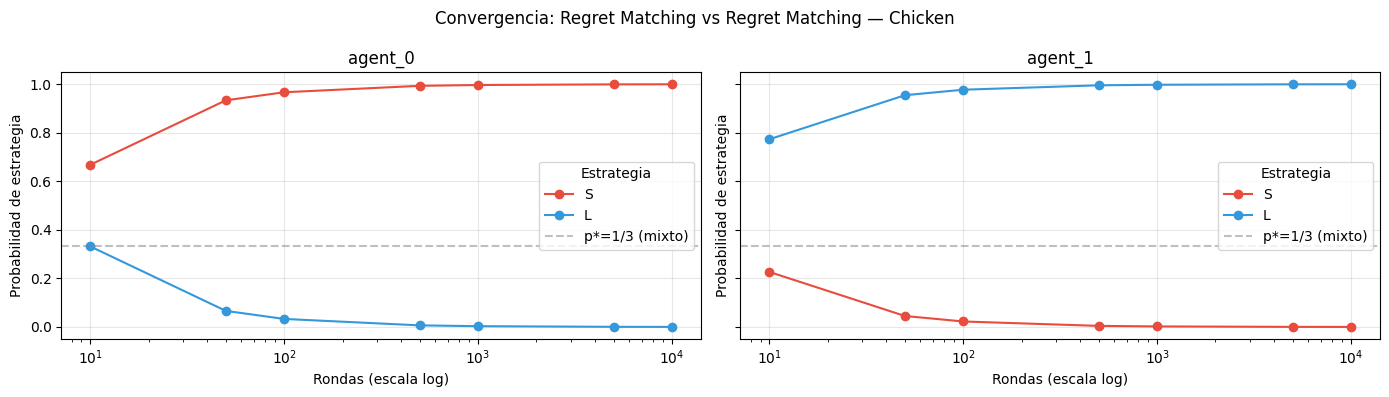

In [18]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Regret Matching vs Regret Matching — Chicken', g)

### Regret Matching vs Random Agent

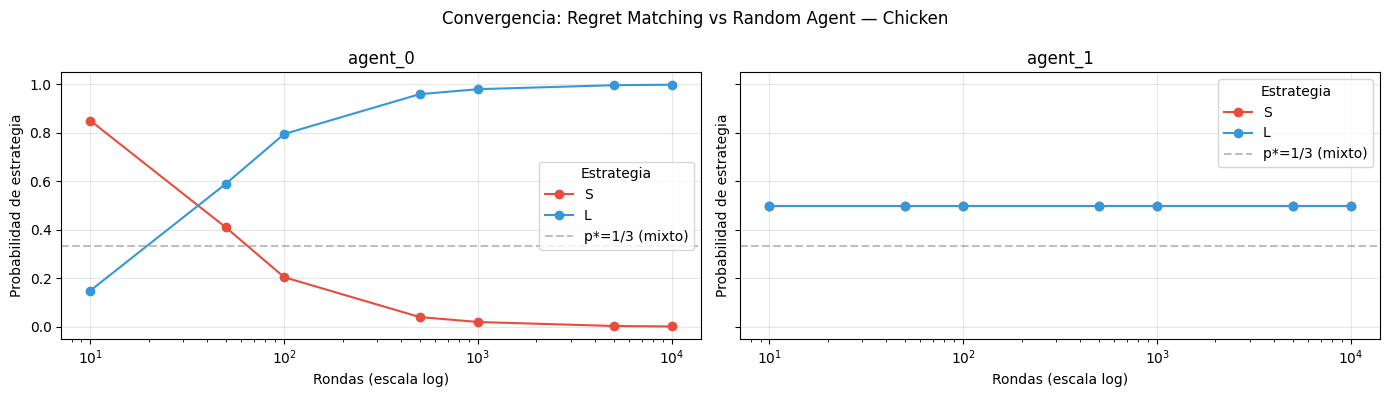

In [19]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Regret Matching vs Random Agent — Chicken', g)

### Fictitious Play vs Fictitious Play

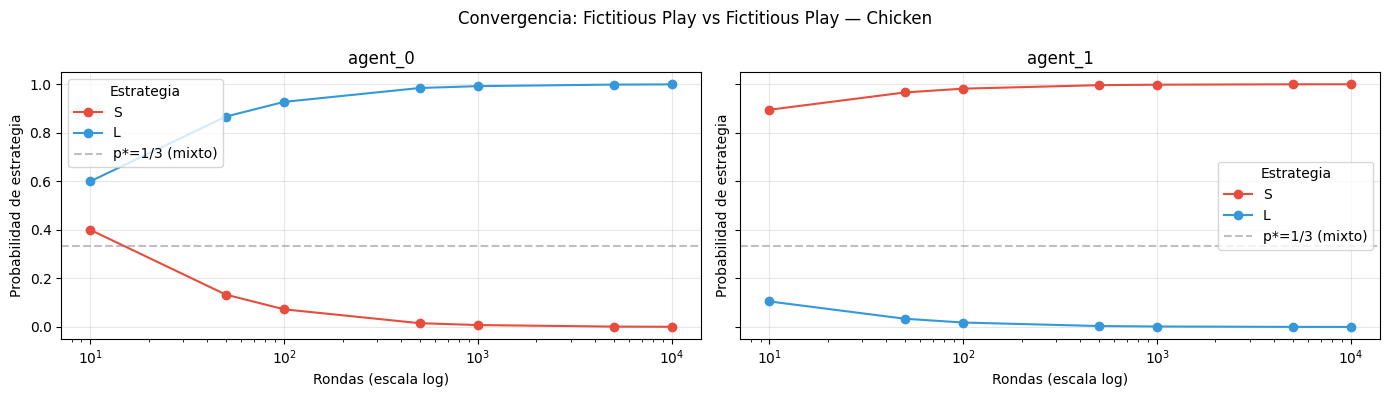

In [20]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Fictitious Play vs Fictitious Play — Chicken', g)

### Fictitious Play vs Random Agent

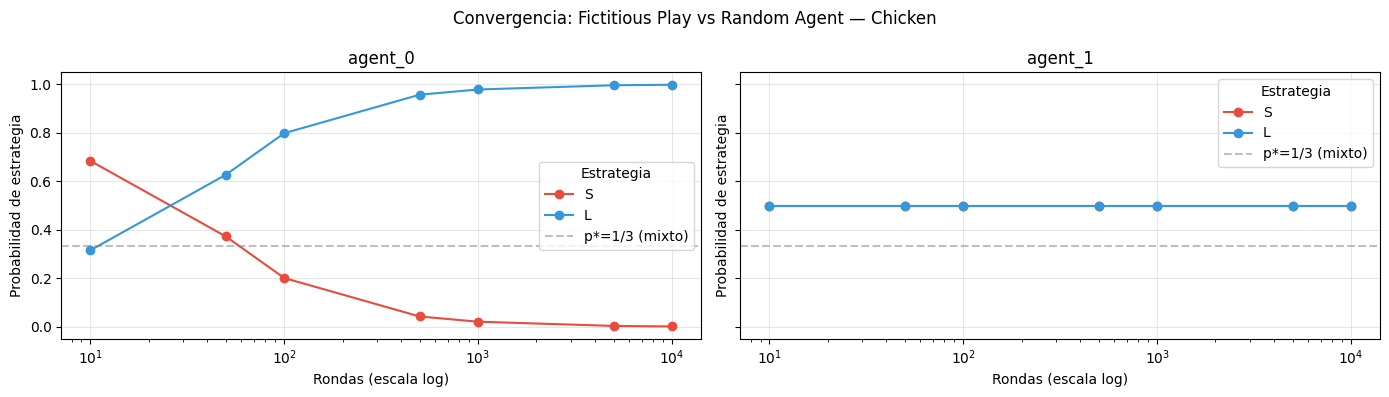

In [21]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Fictitious Play vs Random Agent — Chicken', g)

## Histograma de Acciones Tomadas

Para cada combinación de algoritmos se muestra cuántas veces eligió cada acción durante 10.000 rondas. Permite identificar visualmente hacia qué equilibrio convergen (S ↔ EN asimétrico donde un agente juega S, L ↔ ceder).

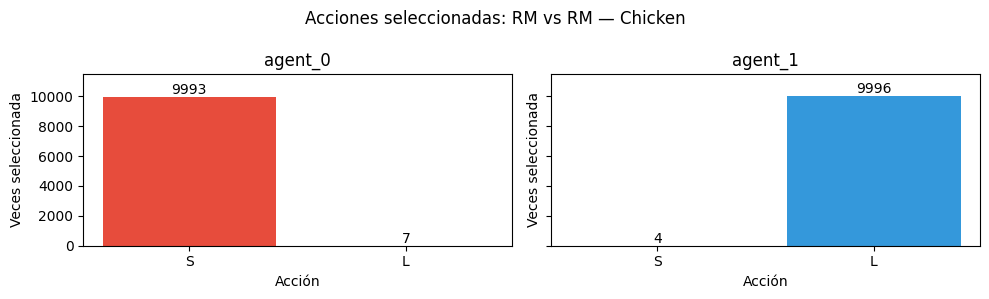

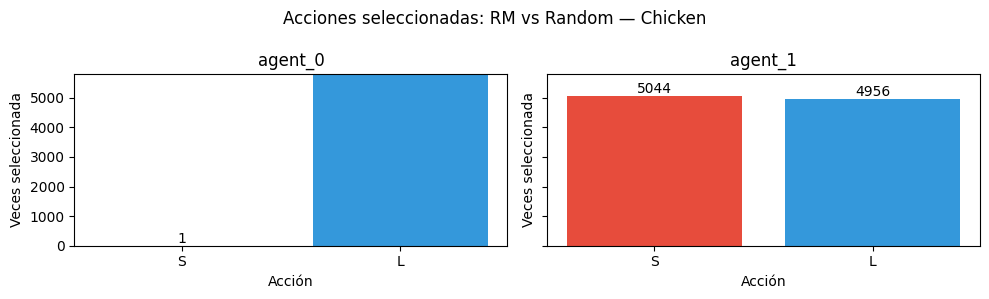

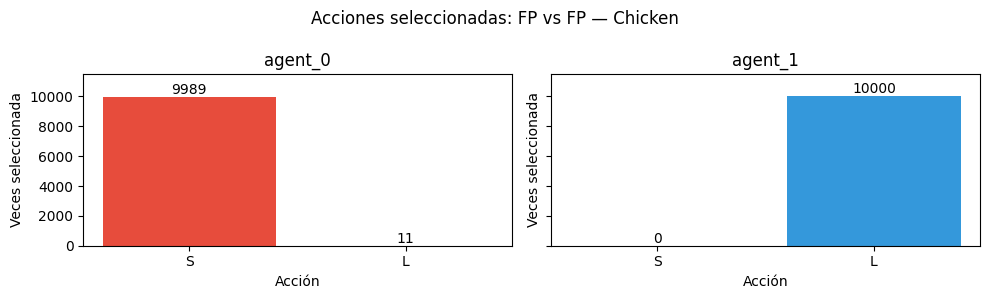

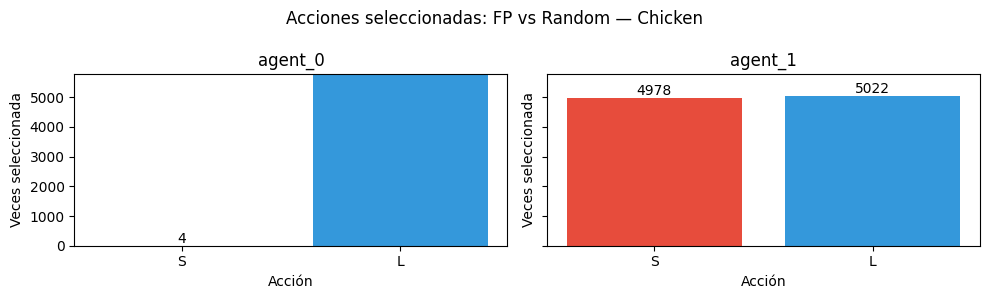

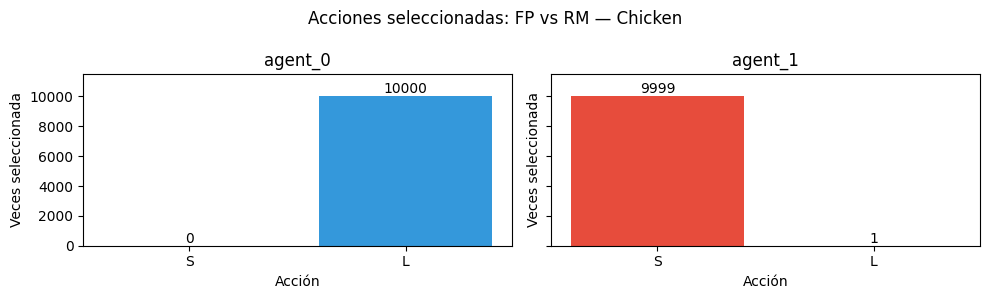

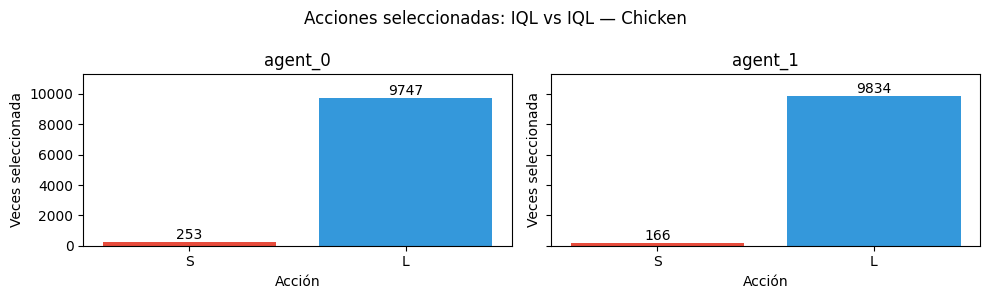

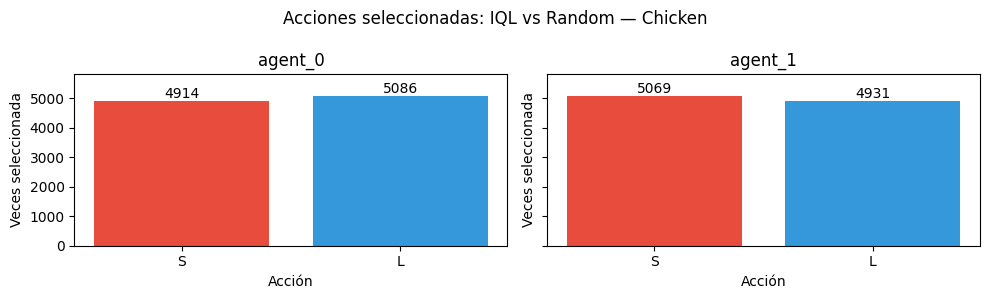

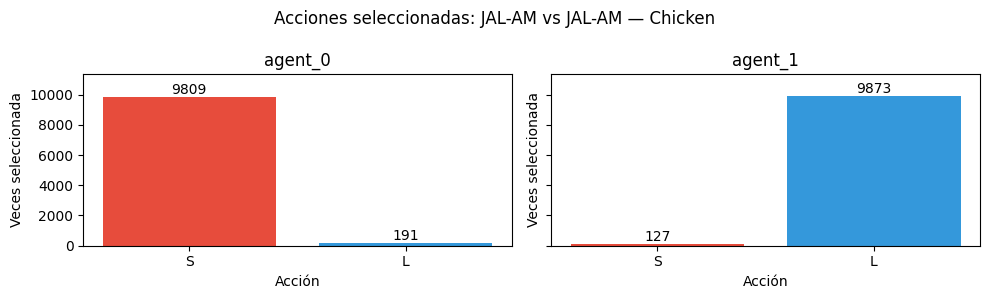

In [22]:
def play_game_with_counts(game, agents, n_rounds=10000):
    """Ejecuta n_rounds y retorna políticas y conteo de acciones por agente."""
    game.reset()
    action_counts = {a: np.zeros(game._num_actions, dtype=int) for a in game.agents}
    for _ in range(n_rounds):
        actions = {a: agents[a].action() for a in game.agents}
        for a in game.agents:
            action_counts[a][actions[a]] += 1
        game.step(actions)
    return {a: agents[a].policy() for a in game.agents}, action_counts


def plot_action_histogram(action_counts, moves, title=''):
    """Histograma de acciones seleccionadas por cada agente."""
    colors = ['#e74c3c', '#3498db']
    fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
    for ax, agent in zip(axes, list(action_counts.keys())):
        counts = action_counts[agent]
        bars = ax.bar(moves, counts, color=colors[:len(moves)])
        ax.bar_label(bars, fmt='%d')
        ax.set_title(agent)
        ax.set_xlabel('Acción')
        ax.set_ylabel('Veces seleccionada')
        ax.set_ylim(0, max(counts) * 1.15)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


histogram_matchups = [
    ('RM vs RM',
     {a: RegretMatching(game=g, agent=a) for a in g.agents}),
    ('RM vs Random',
     {'agent_0': RegretMatching(game=g, agent='agent_0'),
      'agent_1': RandomAgent(game=g, agent='agent_1')}),
    ('FP vs FP',
     {a: FictitiousPlay(game=g, agent=a) for a in g.agents}),
    ('FP vs Random',
     {'agent_0': FictitiousPlay(game=g, agent='agent_0'),
      'agent_1': RandomAgent(game=g, agent='agent_1')}),
    ('FP vs RM',
     {'agent_0': FictitiousPlay(game=g, agent='agent_0'),
      'agent_1': RegretMatching(game=g, agent='agent_1')}),
    ('IQL vs IQL',
     {a: IndependentQLearning(game=g, agent=a) for a in g.agents}),
    ('IQL vs Random',
     {'agent_0': IndependentQLearning(game=g, agent='agent_0'),
      'agent_1': RandomAgent(game=g, agent='agent_1')}),
    ('JAL-AM vs JAL-AM',
     {a: JointActionLearningAM(game=g, agent=a) for a in g.agents}),
]
for title, agents in histogram_matchups:
    _, counts = play_game_with_counts(g, agents)
    plot_action_histogram(counts, move_labels, f'Acciones seleccionadas: {title} — Chicken')


## Análisis de Rewards (multi-seed con IC)

Se extiende el análisis con `N_SEEDS = 10` semillas y `N_EPISODES = 10.000` episodios. Para cada matchup se muestran tres gráficas:

1. **Reward promedio** con banda ±1 std. En Chicken los posibles resultados son: (S,L)=(7,2), (L,S)=(2,7), (S,S)=(0,0), (L,L)=(6,6).
2. **Distancia L1 al EN mixto** $\|\pi_0 - [1/3, 2/3]\|_1$. Nota: distancia alta indica convergencia a un **EN puro** (también válido y de mayor reward para un agente).
3. **P(S) actual vs. promedio acumulado** (seed 0), con líneas de referencia para los equilibrios.

In [23]:

import os
from utils.experiment import run_experiment, run_experiment_and_plot
from utils.io import save_results
from utils.plotting import plot_with_ci, smooth
from utils.metrics import dist_to_ne
from utils.constants import COLORS, IQL_KWARGS, JALAM_KWARGS

N_EPISODES = 10_000
N_SEEDS    = 10
# EN mixto de Chicken: ambos agentes juegan S con p=1/3 y L con p=2/3
NE_CHICKEN = np.array([1/3, 2/3])
os.makedirs('results/Chicken', exist_ok=True)
os.makedirs('figures/Chicken', exist_ok=True)


#### RM vs RM

Saved → results/Chicken/RM_vs_RM/results.json


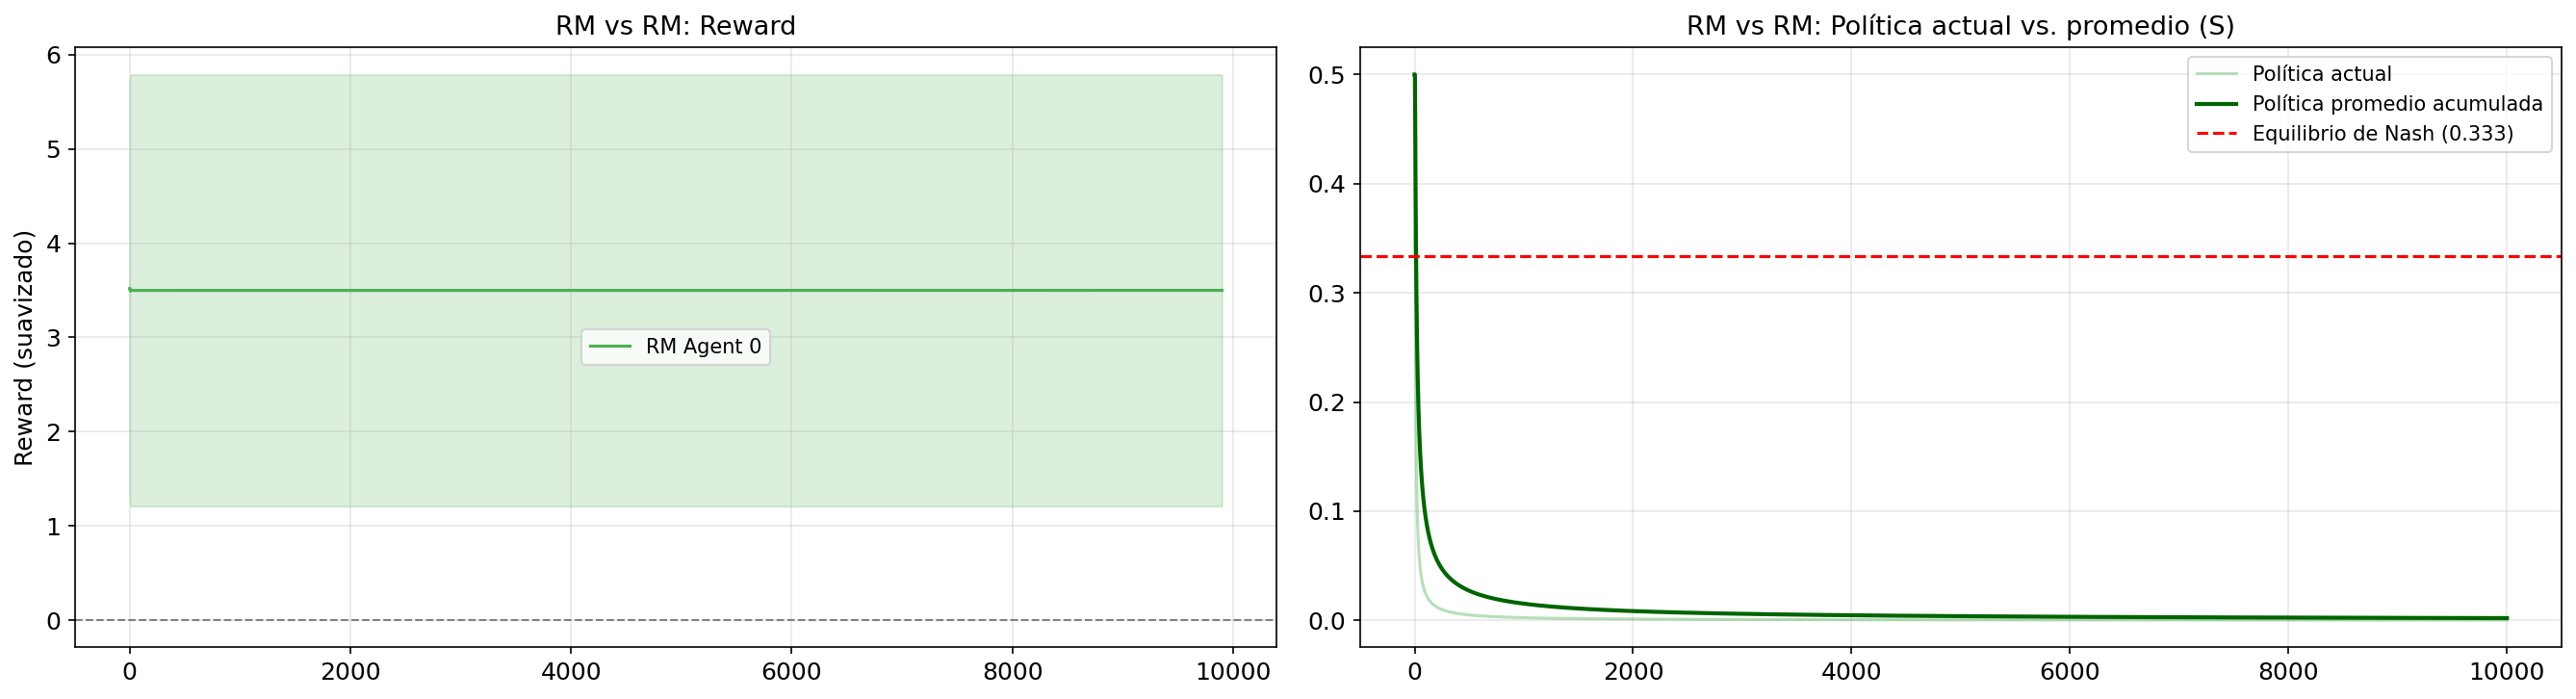

Política final FP (promedio sobre seeds):
  Agent 0: [0.3 0.7]
  Agent 1: [0.7 0.3]
  Equilibrio de Nash: [0.333 0.667]


In [24]:

rewards_rm, pol0_rm, pol1_rm = run_experiment_and_plot(
    Chicken, RegretMatching, RegretMatching,
    NE=NE_CHICKEN, color=COLORS['RM'],
    game_name='Chicken', experiment_name='RM_vs_RM',
    agent0_label='RM', agent1_label='RM',
    action_label='S', action_idx=0,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
)


#### FP vs FP

Saved → results/Chicken/FP_vs_FP/results.json


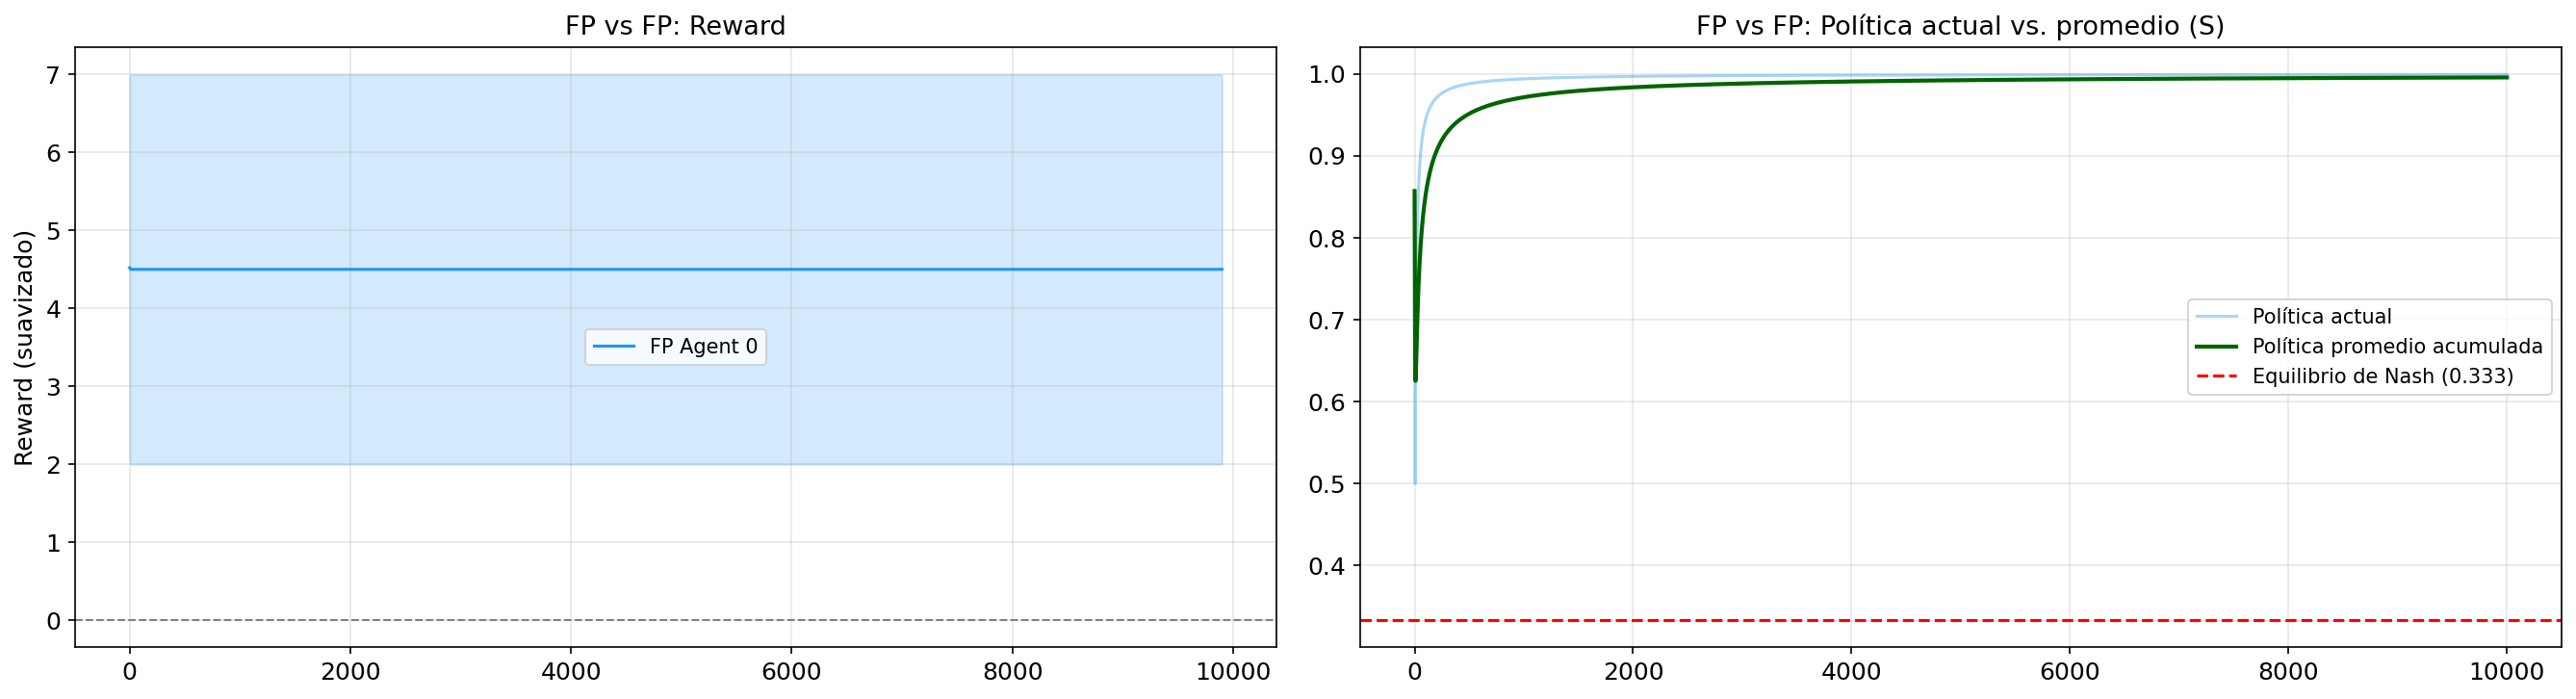

Política final FP (promedio sobre seeds):
  Agent 0: [0.5 0.5]
  Agent 1: [0.5 0.5]
  Equilibrio de Nash: [0.333 0.667]


In [25]:

rewards_fp, pol0_fp, pol1_fp = run_experiment_and_plot(
    Chicken, FictitiousPlay, FictitiousPlay,
    NE=NE_CHICKEN, color=COLORS['FP'],
    game_name='Chicken', experiment_name='FP_vs_FP',
    agent0_label='FP', agent1_label='FP',
    action_label='S', action_idx=0,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
)


#### IQL vs IQL

Saved → results/Chicken/IQL_vs_IQL/results.json


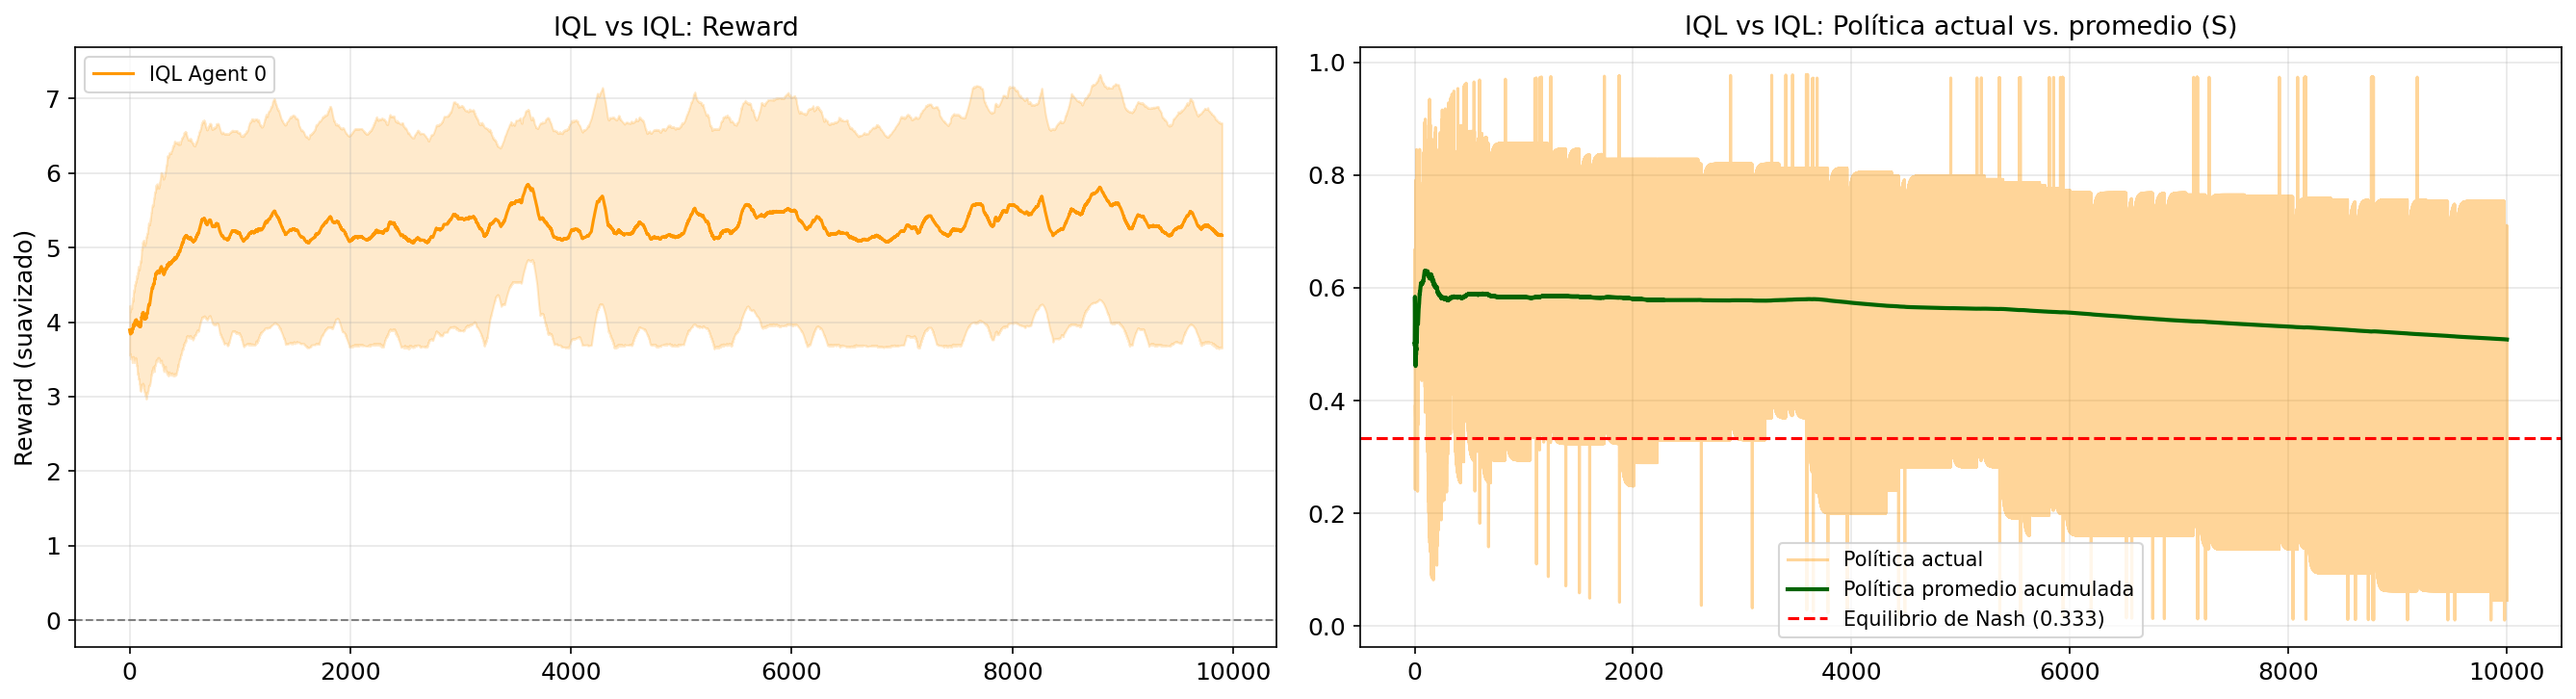

Política final FP (promedio sobre seeds):
  Agent 0: [0.383 0.617]
  Agent 1: [0.37 0.63]
  Equilibrio de Nash: [0.333 0.667]


In [26]:

rewards_iql, pol0_iql, pol1_iql = run_experiment_and_plot(
    Chicken, IndependentQLearning, IndependentQLearning,
    NE=NE_CHICKEN, color=COLORS['IQL'],
    game_name='Chicken', experiment_name='IQL_vs_IQL',
    agent0_label='IQL', agent1_label='IQL',
    action_label='S', action_idx=0,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
    agent0_kwargs=IQL_KWARGS, agent1_kwargs=IQL_KWARGS,
)


#### JAL-AM vs JAL-AM

Saved → results/Chicken/JALAM_vs_JALAM/results.json


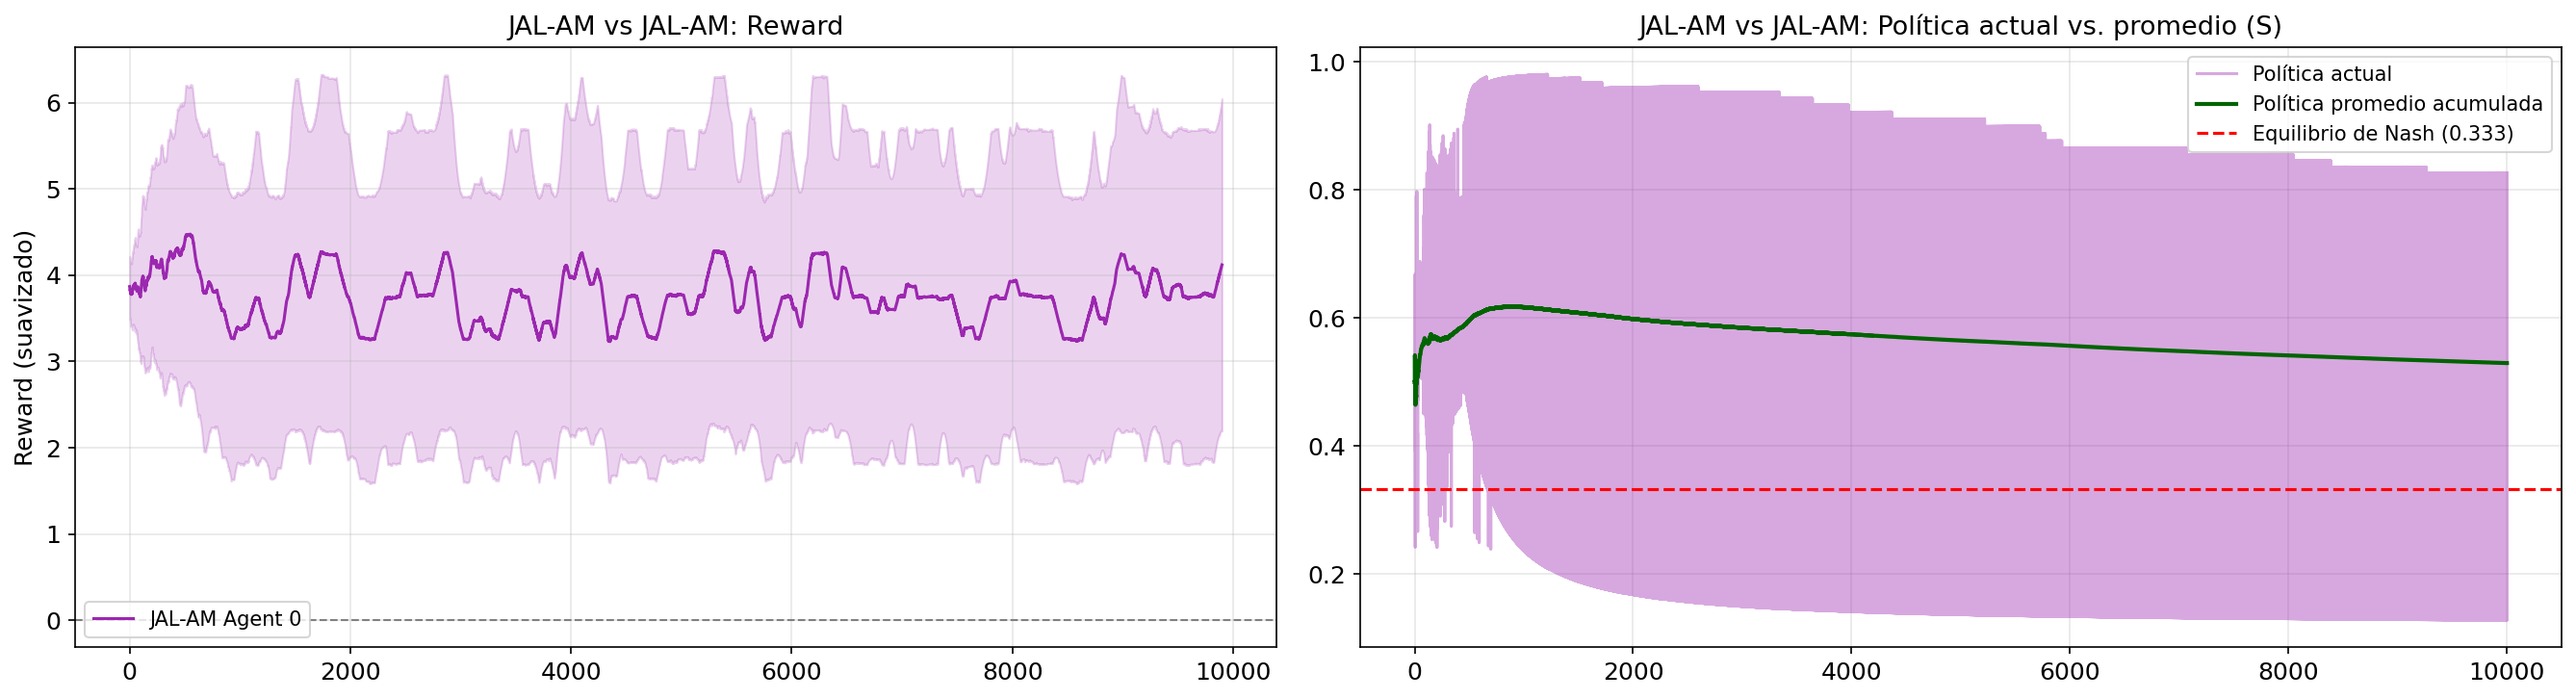

Política final FP (promedio sobre seeds):
  Agent 0: [0.385 0.615]
  Agent 1: [0.474 0.526]
  Equilibrio de Nash: [0.333 0.667]


In [27]:

rewards_jal, pol0_jal, pol1_jal = run_experiment_and_plot(
    Chicken, JointActionLearningAM, JointActionLearningAM,
    NE=NE_CHICKEN, color=COLORS['JAL-AM'],
    game_name='Chicken', experiment_name='JALAM_vs_JALAM',
    agent0_label='JAL-AM', agent1_label='JAL-AM',
    action_label='S', action_idx=0,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
    agent0_kwargs=JALAM_KWARGS, agent1_kwargs=JALAM_KWARGS,
)


#### FP vs RM

Saved → results/Chicken/FP_vs_RM/results.json


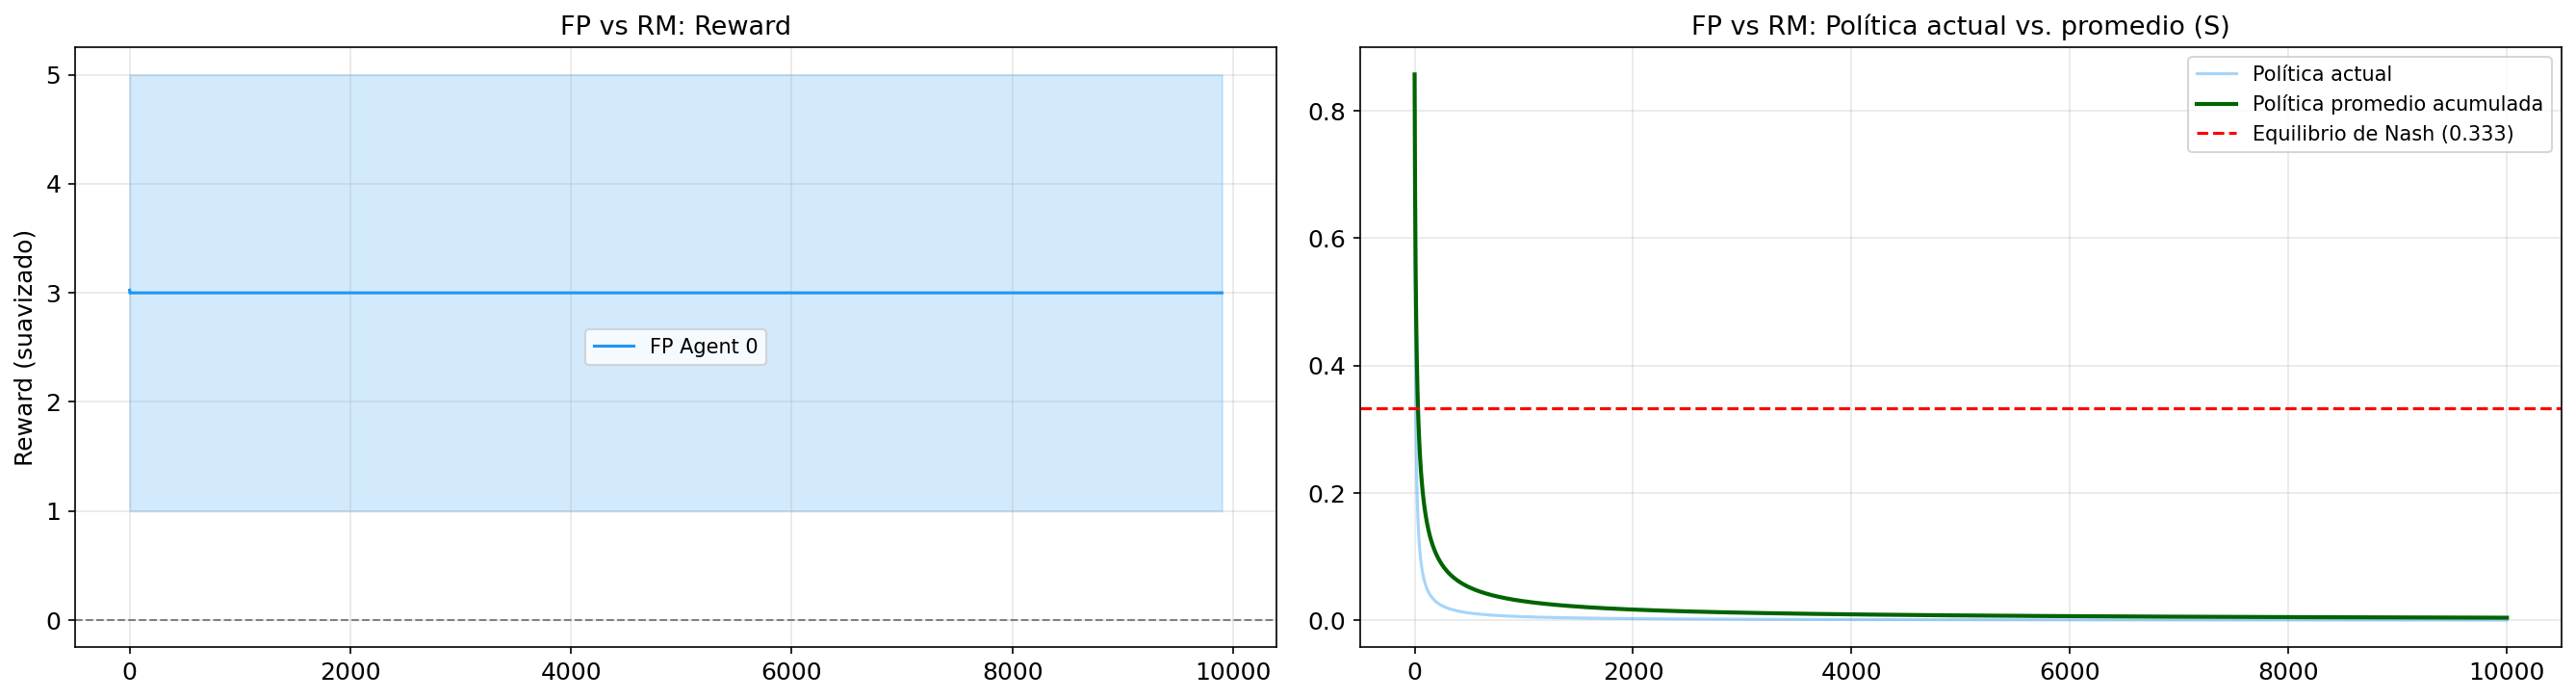

Política final FP (promedio sobre seeds):
  Agent 0: [0.2 0.8]
  Agent 1: [0.8 0.2]
  Equilibrio de Nash: [0.333 0.667]


In [28]:

rewards_fp_rm, pol0_fp_rm, pol1_fp_rm = run_experiment_and_plot(
    Chicken, FictitiousPlay, RegretMatching,
    NE=NE_CHICKEN, color=COLORS['FP'], color1=COLORS['RM'],
    game_name='Chicken', experiment_name='FP_vs_RM',
    agent0_label='FP', agent1_label='RM',
    action_label='S', action_idx=0,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
)


#### Todos vs Random

Saved → results/Chicken/RM_vs_Random/results.json
Saved → results/Chicken/FP_vs_Random/results.json
Saved → results/Chicken/IQL_vs_Random/results.json
Saved → results/Chicken/JALAM_vs_Random/results.json


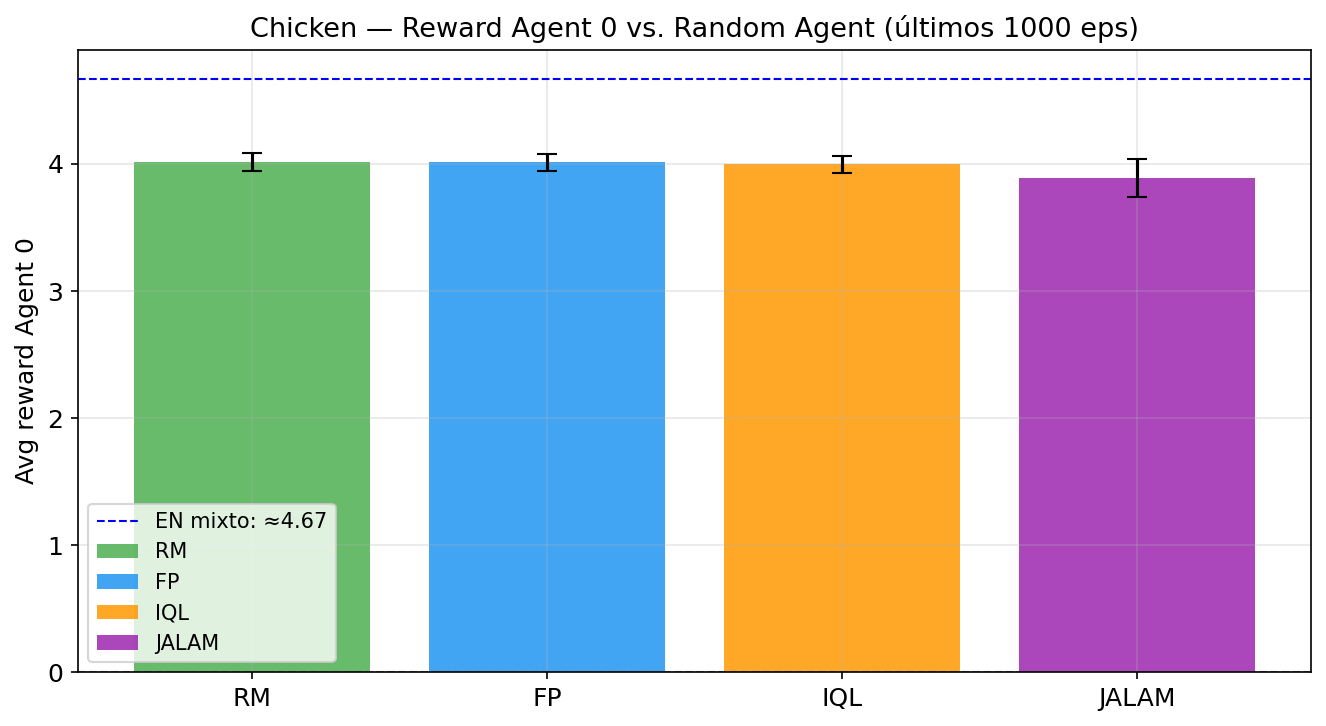

In [29]:

matchups_random_chicken = {
    'RM_vs_Random':    (RegretMatching,        RandomAgent, {}, {}),
    'FP_vs_Random':    (FictitiousPlay,        RandomAgent, {}, {}),
    'IQL_vs_Random':   (IndependentQLearning,  RandomAgent, IQL_KWARGS, {}),
    'JALAM_vs_Random': (JointActionLearningAM, RandomAgent, JALAM_KWARGS, {}),
}
vs_random_chicken = {}
for name, (cls0, cls1, kw0, kw1) in matchups_random_chicken.items():
    r, p0, p1 = run_experiment(Chicken, cls0, cls1, N_EPISODES, N_SEEDS,
                               agent0_kwargs=kw0, agent1_kwargs=kw1)
    vs_random_chicken[name] = (r, p0, p1)
    save_results('Chicken', name, r, p0, p1)

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, (r, _, _)) in enumerate(vs_random_chicken.items()):
    mean_r = r[:, -1000:, 0].mean()
    std_r  = r[:, -1000:, 0].mean(axis=1).std()
    algo = name.split('_vs_')[0]
    ax.bar(i, mean_r, yerr=std_r, color=COLORS.get(algo, 'gray'),
           capsize=5, label=algo, alpha=0.85)
ax.set_xticks(range(len(matchups_random_chicken)))
ax.set_xticklabels([n.split('_vs_')[0] for n in matchups_random_chicken])
ax.set_title('Chicken — Reward Agent 0 vs. Random Agent (últimos 1000 eps)')
ax.set_ylabel('Avg reward Agent 0')
ax.axhline(14/3, ls='--', c='blue', lw=1, label='EN mixto: ≈4.67')
ax.axhline(0,    ls='--', c='gray', lw=1)
ax.legend()
plt.tight_layout()
plt.savefig('figures/Chicken/vs_random_comparison.png', dpi=150)
plt.show()


#### Cross-play: Tasa de Coordinación y Reward Promedio

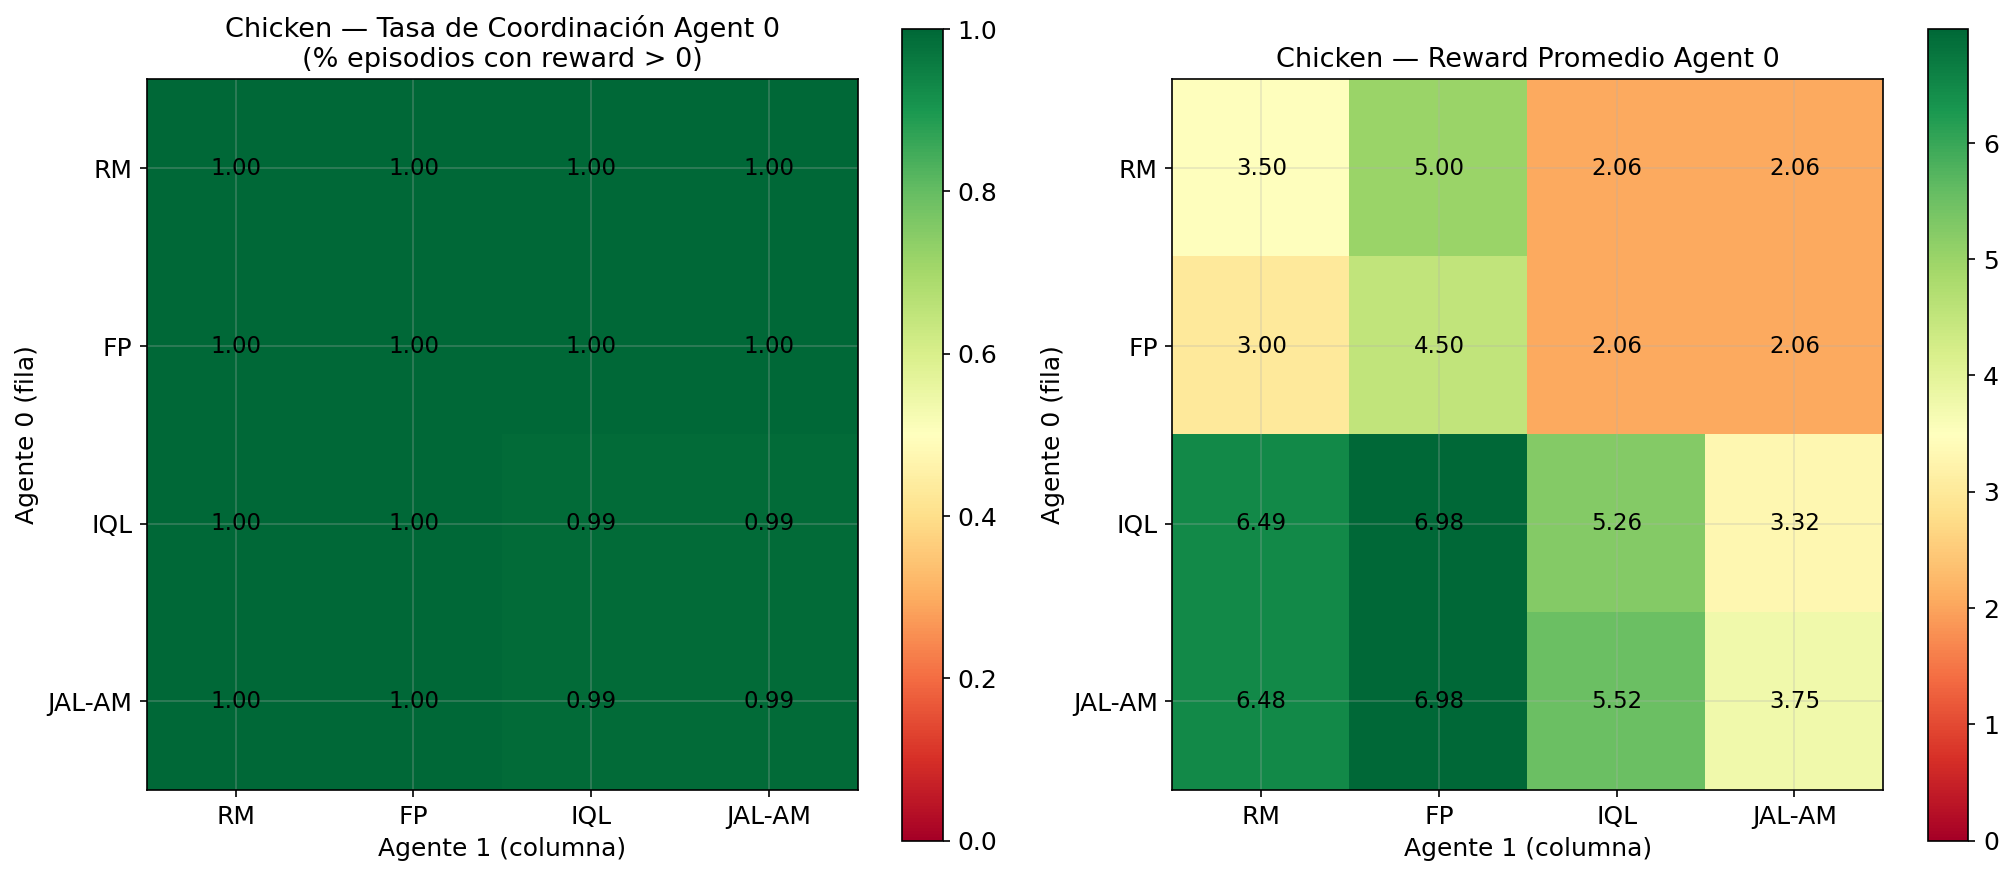

In [30]:

algo_classes_chicken = {
    'RM':     (RegretMatching,        {}),
    'FP':     (FictitiousPlay,        {}),
    'IQL':    (IndependentQLearning,  IQL_KWARGS),
    'JAL-AM': (JointActionLearningAM, JALAM_KWARGS),
}
algos_chicken = list(algo_classes_chicken.keys())
coord_rate_chicken = np.zeros((len(algos_chicken), len(algos_chicken)))
avg_reward_chicken = np.zeros((len(algos_chicken), len(algos_chicken)))

for i, a0 in enumerate(algos_chicken):
    for j, a1 in enumerate(algos_chicken):
        cls0, kw0 = algo_classes_chicken[a0]
        cls1, kw1 = algo_classes_chicken[a1]
        r, _, _ = run_experiment(Chicken, cls0, cls1, N_EPISODES, N_SEEDS,
                                 agent0_kwargs=kw0, agent1_kwargs=kw1)
        coord_rate_chicken[i, j] = (r[:, :, 0] > 0).mean()
        avg_reward_chicken[i, j]  = r[:, :, 0].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, data, title, fmt in [
    (axes[0], coord_rate_chicken, 'Tasa de Coordinación Agent 0\n(% episodios con reward > 0)', '{:.2f}'),
    (axes[1], avg_reward_chicken, 'Reward Promedio Agent 0',                                    '{:.2f}'),
]:
    im = ax.imshow(data, cmap='RdYlGn', vmin=0, vmax=data.max())
    ax.set_xticks(range(len(algos_chicken))); ax.set_yticks(range(len(algos_chicken)))
    ax.set_xticklabels(algos_chicken); ax.set_yticklabels(algos_chicken)
    ax.set_xlabel('Agente 1 (columna)'); ax.set_ylabel('Agente 0 (fila)')
    ax.set_title(f'Chicken — {title}')
    plt.colorbar(im, ax=ax)
    for ii in range(len(algos_chicken)):
        for jj in range(len(algos_chicken)):
            ax.text(jj, ii, fmt.format(data[ii, jj]), ha='center', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('figures/Chicken/cross_play_matrix.png', dpi=150)
plt.show()


#### Comparación final: todos los algoritmos

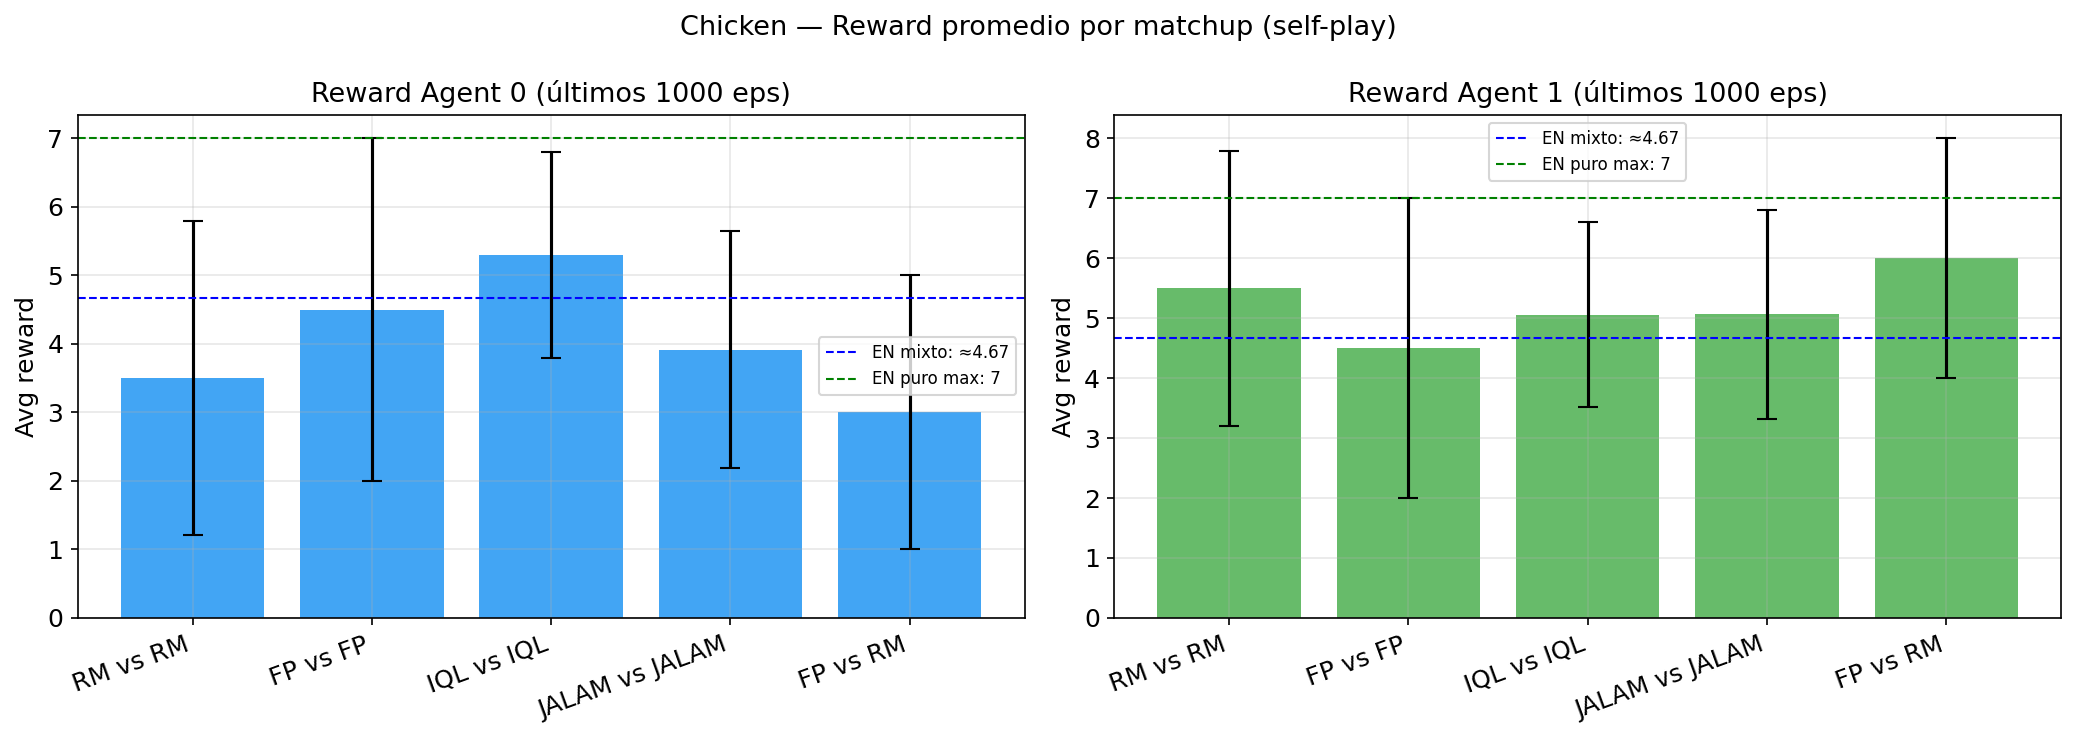

Matchup                       Política final A0   Dist NE (media)   Dist NE (std)
---------------------------------------------------------------------------------
RM vs RM                              [0.3 0.7]            0.8661          0.3054
FP vs FP                              [0.5 0.5]            0.9986          0.3332
IQL vs IQL                        [0.393 0.607]            0.4076          0.2301
JALAM vs JALAM                    [0.364 0.636]            0.5825          0.1468
FP vs RM                              [0.2 0.8]            0.7988          0.2667


In [31]:

# Reward promedio (últimos 1000 eps) por matchup
self_play_results = {
    'RM vs RM':       (rewards_rm,    pol0_rm,    pol1_rm),
    'FP vs FP':       (rewards_fp,    pol0_fp,    pol1_fp),
    'IQL vs IQL':     (rewards_iql,   pol0_iql,   pol1_iql),
    'JALAM vs JALAM': (rewards_jal,   pol0_jal,   pol1_jal),
    'FP vs RM':       (rewards_fp_rm, pol0_fp_rm, pol1_fp_rm),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names    = list(self_play_results.keys())
r0_means = [self_play_results[n][0][:, -1000:, 0].mean() for n in names]
r1_means = [self_play_results[n][0][:, -1000:, 1].mean() for n in names]
r0_stds  = [self_play_results[n][0][:, -1000:, 0].mean(axis=1).std() for n in names]
r1_stds  = [self_play_results[n][0][:, -1000:, 1].mean(axis=1).std() for n in names]
x = range(len(names))

axes[0].bar(x, r0_means, yerr=r0_stds, capsize=5, alpha=0.85, color=COLORS['FP'])
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=20, ha='right')
axes[0].set_title('Reward Agent 0 (últimos 1000 eps)'); axes[0].set_ylabel('Avg reward')
axes[0].axhline(14/3, ls='--', c='blue',  lw=1, label='EN mixto: ≈4.67')
axes[0].axhline(7,    ls='--', c='green', lw=1, label='EN puro max: 7'); axes[0].legend(fontsize=8)

axes[1].bar(x, r1_means, yerr=r1_stds, capsize=5, alpha=0.85, color=COLORS['RM'])
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=20, ha='right')
axes[1].set_title('Reward Agent 1 (últimos 1000 eps)'); axes[1].set_ylabel('Avg reward')
axes[1].axhline(14/3, ls='--', c='blue',  lw=1, label='EN mixto: ≈4.67')
axes[1].axhline(7,    ls='--', c='green', lw=1, label='EN puro max: 7'); axes[1].legend(fontsize=8)

plt.suptitle('Chicken — Reward promedio por matchup (self-play)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/Chicken/reward_comparison.png', dpi=150)
plt.show()

from utils.plotting import summary_table
summary_table(self_play_results, ne=NE_CHICKEN)


### Conclusiones
- El juego Chicken presenta **dos equilibrios puros asimétricos** (S,L) y (L,S) y un **equilibrio mixto** con p*=1/3, lo que lo distingue de juegos con equilibrio único.
- **Regret Matching** tiende a converger al equilibrio mixto cuando se enfrenta a sí mismo, ya que ambos agentes acumulan regrets similares y no logran coordinar en un equilibrio puro.
- **Fictitious Play** es el algoritmo más propenso a encontrar un equilibrio puro asimétrico: al modelar las frecuencias del oponente, uno de los dos agentes se vuelve el "valiente" (S) mientras el otro cede (L).
- **Random Agent** mantiene la distribución uniforme (S=0.5, L=0.5), lo que presiona a los algoritmos adaptativos a responder con la mejor respuesta pura: S con mayor frecuencia (ya que en promedio el oponente juega L el 50% del tiempo y S da 7 vs L da 6).
